# QAT Bit-Width Sweep and Pareto Analysis

Execute a sweep over HGQ2 quantizer bit-width parameters and visualize the accuracy vs resource trade-off.

All sweep logic lives in ``bedposip.model.sweep`` — this notebook just orchestrates and visualizes.

## Imports

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt

from bedposip.model import run_sweep, plot_pareto, print_pareto_summary

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1780596329.064760   38451 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Run sweep

Sweep over random quantizer configurations. Results are returned as a DataFrame.

In [2]:
# Run 20 trials (adjust as needed)
df = run_sweep(
    trials=5,
    notebook_path=Path('train_quantized_cnn.ipynb'),
)

Total combinations: 5
[1/5] run_0001: {'weight_i0': 1, 'weight_b0': 5, 'bias_i0': 3, 'bias_b0': 4, 'datalane_i0': 2, 'datalane_f0': 4}


I0000 00:00:1780596331.635819   38487 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780596333.996765   38487 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4789 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1780596342.670461   38572 service.cc:153] XLA service 0x7efa9406d300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780596342.670475   38572 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780596342.954248   38572 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=0.58, Acc=0.8293, EBOPs=890080, LUTs=724749, DSPs=3006
[2/5] run_0002: {'weight_i0': 1, 'weight_b0': 6, 'bias_i0': 3, 'bias_b0': 4, 'datalane_i0': 3, 'datalane_f0': 1}


I0000 00:00:1780596545.434812   56048 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780596548.153543   56048 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1780596556.782336   56126 service.cc:153] XLA service 0x7f5be4063860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780596556.782349   56126 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780596557.076302   56126 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=3.4, Acc=0.4285, EBOPs=303724, LUTs=251329, DSPs=953
[3/5] run_0003: {'weight_i0': 2, 'weight_b0': 4, 'bias_i0': 2, 'bias_b0': 6, 'datalane_i0': 1, 'datalane_f0': 4}


...

  [OK] Loss=1.22, Acc=0.7909, EBOPs=779538, LUTs=636004, DSPs=2610
[4/5] run_0004: {'weight_i0': 1, 'weight_b0': 4, 'bias_i0': 4, 'bias_b0': 6, 'datalane_i0': 4, 'datalane_f0': 2}


I0000 00:00:1780596954.168501   86285 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780596956.344120   86285 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4807 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1780596964.872252   86355 service.cc:153] XLA service 0x7ff3a80625b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780596964.872267   86355 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780596965.189745   86355 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=1.89, Acc=0.5792, EBOPs=465171, LUTs=382471, DSPs=1504
[5/5] run_0005: {'weight_i0': 1, 'weight_b0': 8, 'bias_i0': 3, 'bias_b0': 5, 'datalane_i0': 1, 'datalane_f0': 3}


I0000 00:00:1780597175.568327  105009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780597177.603376  105009 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1780597185.934523  105083 service.cc:153] XLA service 0x7f633406b380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780597185.934537  105083 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780597186.271535  105083 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=3.32, Acc=0.4526, EBOPs=450890, LUTs=370902, DSPs=1454

Done. 5 results collected.


### Accuracy vs EBOPs

EBOPs is a proxy for dynamic power consumption. Lower is better.

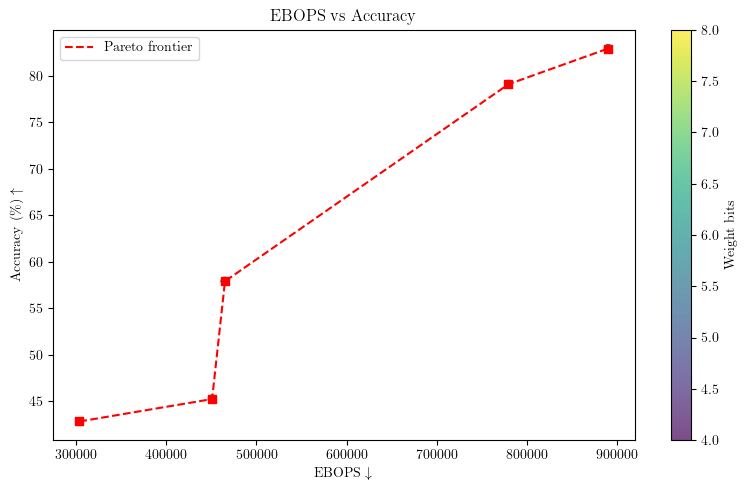

In [3]:
plot_pareto(
    df,
    resource='ebops',
    filename='pareto_ebops',
)

### Accuracy vs LUTs

LUTs measure FPGA fabric usage. Lower is better.

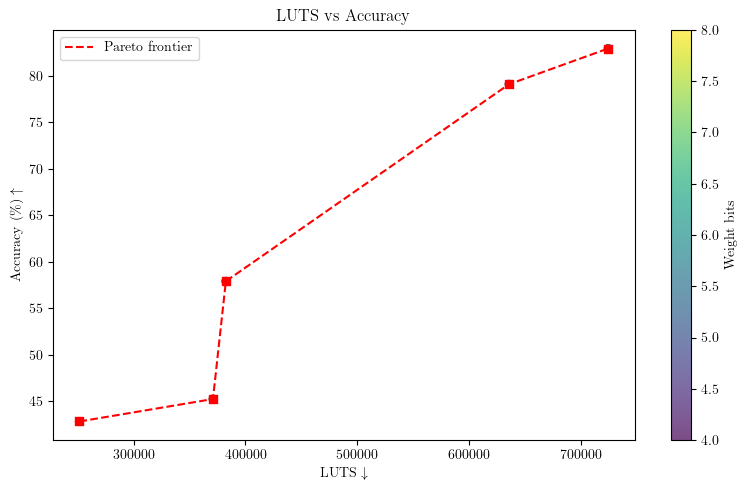

In [4]:
plot_pareto(
    df,
    resource='luts',
    filename='pareto_luts',
)

### Accuracy vs DSPs

DSPs are dedicated arithmetic blocks on the FPGA. Lower is better.

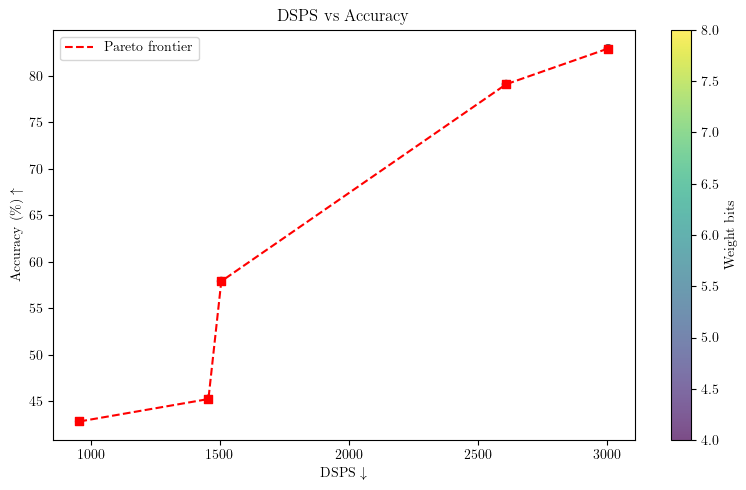

In [5]:
plot_pareto(
    df,
    resource='dsps',
    filename='pareto_dsps',
)

## Pareto summary (accuracy >= 80%)

In [6]:
for resource in ['ebops', 'luts', 'dsps']:
    print_pareto_summary(df, resource=resource, threshold=0.80)
    print()

Runs with accuracy >= 80%: 1 out of 5

Pareto-optimal configurations (accuracy >= 80%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_i0 w_b0 b_i0 b_b0 d_i0 d_f0
---------------------------------------------------------------------------
run_0001      82.9%   890080   724749   3006     1    5    3    4    2    4

Runs with accuracy >= 80%: 1 out of 5

Pareto-optimal configurations (accuracy >= 80%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_i0 w_b0 b_i0 b_b0 d_i0 d_f0
---------------------------------------------------------------------------
run_0001      82.9%   890080   724749   3006     1    5    3    4    2    4

Runs with accuracy >= 80%: 1 out of 5

Pareto-optimal configurations (accuracy >= 80%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_i0 w_b0 b_i0 b_b0 d_i0 d_f0
---------------------------------------------------------------------------
run_0001      82.9%   890080   724749   3006     1    5    3    4    2    4

